# **Task 1 - Implementation of MCP Neurons**

**1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two
inputs:**

In [59]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1D array): An array of binary values.
  X2 (1D array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """

  assert len(X1) == len(X2)

  # Element-wise addition of two input arrays
  aggregated = [X1[i] + X2[i] for i in range(len(X1))]

  # Create output list
  state_neuron = []

  # Append 1 if sum >= Threshold, else append 0
  for element in aggregated:
    if element >=T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron


X1 = [0,0,1,1]
X2 = [0,1,0,1]
T_AND = 2

result_and = MCP_Neurons_AND(X1, X2, T_AND)
print(f"AND Gate (T={T_AND})")
print(f"X1:     {X1}")
print(f"X2:     {X2}")
print(f"Output: {result_and}\n")


AND Gate (T=2)
X1:     [0, 0, 1, 1]
X2:     [0, 1, 0, 1]
Output: [0, 0, 0, 1]



In [60]:
def MCP_Neurons_OR(X1, X2, T):
  """
  This functions implements basic OR operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1D array): An array of binary values.
  X2 (1D array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """

  assert len(X1) == len(X2)

  # Element-wise addition of two input arrays
  aggregated = [X1[i] + X2[i] for i in range(len(X1))]

  # Create output list
  state_neuron = []

  # Append 1 if sum >= Threshold, else append 0
  for element in aggregated:
    if element >=T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron


X1 = [0,0,1,1]
X2 = [0,1,0,1]
T_OR = 1

result_and = MCP_Neurons_OR(X1, X2, T_OR)
print(f"OR Gate (T={T_OR})")
print(f"X1:     {X1}")
print(f"X2:     {X2}")
print(f"Output: {result_and}\n")


OR Gate (T=1)
X1:     [0, 0, 1, 1]
X2:     [0, 1, 0, 1]
Output: [0, 1, 1, 1]



# **Exercise 3.2.1 - Answer the Following Question**

 **Question 1 - List out all the limitations of MCP - Neurons.**

The limitations of MCP Neurons are as follows:

1. Binary Inputs and Outputs Only
2. Fixed and Hand-Crafted Weights (1)
3. No Learning Ability
4. Cannot Solve Non-Linearly Seperable Problems
5. No Inhibitory Input  Handling (Limited)
6. Threshold is Manually Determined
7. Cannot Handle Missing or Noisy Data
8. No Bias Term
10. Not Biologicallyy Accutrate Enough
11. Does not Scale to Complex Problems

**Question 2 - Think if you can develop a logic to solve for XOR function using MCP Neuron.**

In [61]:
def MCP_Neurons_XOR(X1, X2):
  """
  This functions implements XOR operation with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1D array): An array of binary values.
  X2 (1D array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """

  assert len(X1) == len(X2)

  # Create output list
  state_neuron = []

  for i in range (len(X1)):

    # Aggregate Inputs
    total = X1[i] + X2[i]

    # OR condition - at least one input is 1 (total >=1)
    OR_result = 1 if total >= 1 else 0

    # NAND conditionn - NOT both inputs are 1 (total < 2)
    NAND_result = 1 if total < 2 else 0

    # XOR = OR AND NAND
    if OR_result == 1 and NAND_result == 1:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

X1 = [0,0,1,1]
X2 = [0,1,0,1]

result_xor = MCP_Neurons_XOR(X1, X2)
print(f"XOR Gate")
print(f"X1:     {X1}")
print(f"X2:     {X2}")
print(f"Output: {result_xor}\n")


XOR Gate
X1:     [0, 0, 1, 1]
X2:     [0, 1, 0, 1]
Output: [0, 1, 1, 0]



# **Task 2 - Perceptron Algorithm for 0 vs 1 Classification**

**1. Load the Dataset**

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/SEM6_AI/Week3/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


**Question 1 - What does the shape of X represent?**

X holds all the input features (pixel intensities) for every image.

**Question 2 - What does the shape of X represent?**

Y holds the actual digit identity of each image.

**2. Visualize the Dataset**

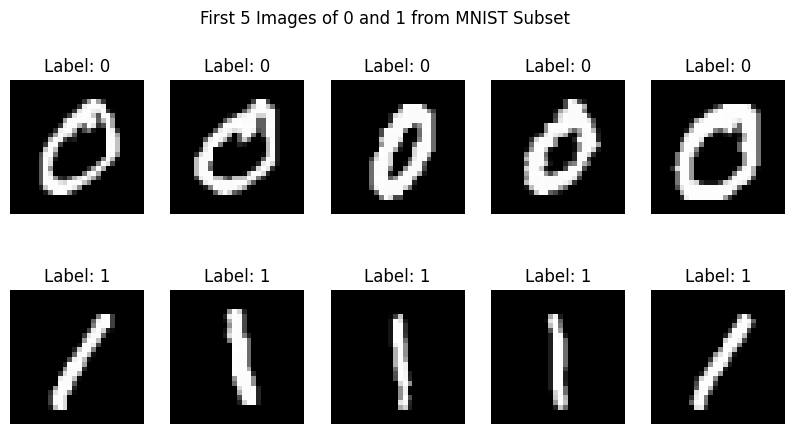

In [63]:
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    # Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    # Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
  plt.show()

**3. Initialize Weights and Bias**

In [64]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**Question 3 - What does the weights array represent in this context?**

Here, weights creates an array of 784 seros (one for each pixel in a 28x28 image). So, all weights atart at 0. During training over 100 epochs, weights are updated gradually using the learning rate (0.1) to  learn which pizels matter most for classification.

**Question 4 - Why are we initializing the weights to zero? What effect could this have on the training process?**

Zero initialization works in this case as each weight updates independently based on its own pixel value. DIfferent pixels have different values, so weights will diverge and learn differently over time.

After the first update, sinch each pixel value is different, each weight gets a different update so weights will not stay equal after the fiest update. SO no problem shall occur duiring the training process.

**4. Implement a Decision Function or Activation Function**

In [65]:
import numpy as np
def decision_function(X, weights, bias):
  """
  Compute the predicted labels for the input data.
  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - weights: Updated weights after training
  - bias: Updated bias after training
  Returns:
  - y_pred_all: The predicted labels for the input data
  """
  predictions = np.dot(X, weights) + bias

  # Activation function (step function)
  y_pred_all = np.where(predictions >= 0,1,0)

  return y_pred_all

If a pixel location is typically WHITE for digit '1'

-> assign POSITIVE weight

If a pixel location is typically WHITE for digit '0'

-> assign NEGATIVE weight

If a pixel location is BLACK for BOTH digits

-> assign ZERO weight

**5. Implement the Perceptron Learning Algorithm**

In [66]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
  """
  Train the perceptron using the Perceptron Learning Algorithm.
  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - y: Labels (true output) as a numpy array of shape (n_samples,)
  - weights: Initial weights as a numpy array of shape (n_features,)
  - bias: Initial bias value (scalar)
  - learning_rate: Learning rate for weight updates (default is 0.1)
  - epochs: Number of iterations to train the model (default is 100)
  Returns:
  - weights: Updated weights after training
  - bias: Updated bias after training
  - accuracy: Total correct prediction.
  """
  # Perceptron Learning Algorithm
  for epoch in range(epochs):
    correct_predictions = 0

    for i in range(len(X)):
      y_pred = decision_function(X[i], weights, bias)
      error = y[i] - y_pred

      if error != 0:
        weights = weights + (learning_rate * error * X[i])
        bias = bias + (learning_rate * error)

      if error == 0:
        correct_predictions += 1

    accuracy = correct_predictions / len(X)

    if (epoch + 1)% 10 == 0:
      print(f"Epoch {epoch + 1}/{epochs} → Accuracy: {accuracy * 100:.2f}%")

  return weights, bias, accuracy

**Question 5 - What is the purpose of the predictions = np.dot(X[i], weights) + bias line?**

The above line computes the weighted sum of input features plus bias, producing the activation value used by the perceptron to determine the predicted class.

**Question 6 - What happens when the prediction is wrong? How are the weights and
bias updated?**

When the prediction is wrong (error ≠ 0), the perceptron updates the weights and bias using the learning rate and error. The weights are adjusted in the direction of the input features, and the bias is shifted to move the decision boundary toward correct classification.

**Question 7 - Why is the final accuracy important, and what do you expect it to be?**

Final accuracy is important because it indicates how well the perceptron has learned to classify the data. For linearly separable data, the accuracy is expected to reach 100%, while for non-linearly separable data, it will be lower.

**6. Putting it all Together**

In [67]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print(f"The Final Accuracy is: {accuracy * 100:.2f}%")

Epoch 10/100 → Accuracy: 99.92%
Epoch 20/100 → Accuracy: 100.00%
Epoch 30/100 → Accuracy: 100.00%
Epoch 40/100 → Accuracy: 100.00%
Epoch 50/100 → Accuracy: 100.00%
Epoch 60/100 → Accuracy: 100.00%
Epoch 70/100 → Accuracy: 100.00%
Epoch 80/100 → Accuracy: 100.00%
Epoch 90/100 → Accuracy: 100.00%
Epoch 100/100 → Accuracy: 100.00%
The Final Accuracy is: 100.00%


**7. Visualizing the Misclassified Image**

In [68]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy * 100:.2f}%")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 100.00%
All images were correctly classified!


**Question 8 - What does misclassified_idx store, and how is it used in this code?**

***misclassified_idx*** stores the indices of all incorrectly classified samples. It is used to retrieve and display those misclassified images along with their predicted and true labels for error analysis.

**Question 9 - How do you interpret the result if the output is ”All images were
correctly classified!”?**

This output means that the model correctly classified all samples, resulting in 100% accuracy. It indicates that the dataset is linearly separable and the perceptron has successfully learned the decision boundary.

# **Task 3 - Perceptron Algorithm for 3 vs 5 Classification**

**1. Load the Dataaset**

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/SEM6_AI/Week3/mnist_3_and_5.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_3_5.drop(columns=["label"]).values # 784 pixels
y = df_3_5["label"].values # Labels (3 or 5)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


**2. Visualize the Dataset**

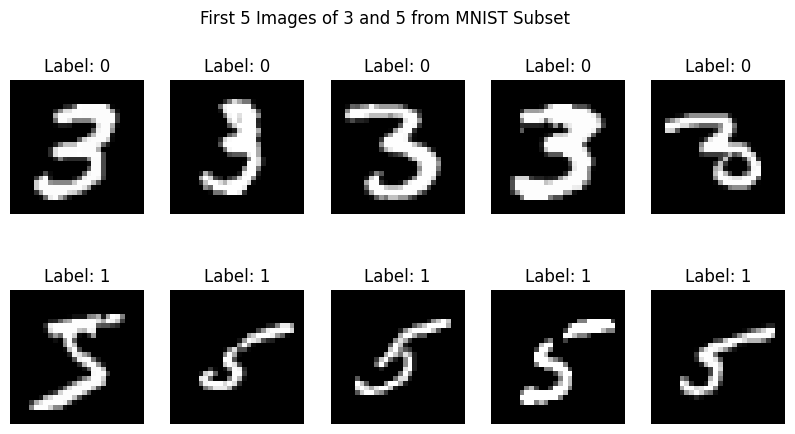

In [70]:
# Separate images for label 0 and label 1
images_3 = X[y == 3] # Get all images with label 3
images_5 = X[y == 5] # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
  print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
  for i in range(5):
    # Plot digit 0
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    # Plot digit 1
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
  plt.show()

**3. Initialize Weights and Bias**

In [71]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**4. Implement a Decision Function or Activation Function**

In [72]:
import numpy as np
def decision_function(X, weights, bias):
  """
  Compute the predicted labels for the input data.
  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - weights: Updated weights after training
  - bias: Updated bias after training
  Returns:
  - y_pred_all: The predicted labels for the input data
  """
  predictions = np.dot(X, weights) + bias

  # Activation function (step function)
  y_pred_all = np.where(predictions >= 0,1,0)

  return y_pred_all

**5. Implement the Perceptron Learning Algorithm**

In [73]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
  """
  Train the perceptron using the Perceptron Learning Algorithm.
  Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - y: Labels (true output) as a numpy array of shape (n_samples,)
  - weights: Initial weights as a numpy array of shape (n_features,)
  - bias: Initial bias value (scalar)
  - learning_rate: Learning rate for weight updates (default is 0.1)
  - epochs: Number of iterations to train the model (default is 100)
  Returns:
  - weights: Updated weights after training
  - bias: Updated bias after training
  - accuracy: Total correct prediction.
  """
  # Perceptron Learning Algorithm
  for epoch in range(epochs):
    correct_predictions = 0

    for i in range(len(X)):
      y_pred = decision_function(X[i], weights, bias)

      #map back to 3 or 5
      y_pred_digits = np.where(y_pred == 1, 5, 3)
      error = y[i] - y_pred

      if error != 0:
        weights = weights + (learning_rate * error * X[i])
        bias = bias + (learning_rate * error)

      if error == 0:
        correct_predictions += 1

    accuracy = correct_predictions / len(X)

    if (epoch + 1)% 10 == 0:
      print(f"Epoch {epoch + 1}/{epochs} → Accuracy: {accuracy * 100:.2f}%")

  return weights, bias, accuracy

**6. Putting it all Together**

In [74]:
# Convert 3/5 labels into 0/1 for training
y_binary = np.where(y == 5, 1, 0)

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y_binary, weights, bias)
# Evaluate the model using the new function
print(f"The Final Accuracy is: {accuracy * 100:.2f}%")

Epoch 10/100 → Accuracy: 95.66%
Epoch 20/100 → Accuracy: 96.61%
Epoch 30/100 → Accuracy: 97.26%
Epoch 40/100 → Accuracy: 97.19%
Epoch 50/100 → Accuracy: 97.88%
Epoch 60/100 → Accuracy: 97.59%
Epoch 70/100 → Accuracy: 97.92%
Epoch 80/100 → Accuracy: 97.92%
Epoch 90/100 → Accuracy: 98.43%
Epoch 100/100 → Accuracy: 98.58%
The Final Accuracy is: 98.58%


**7. Visualizing the Misclassified Image**

Final Accuracy: 98.69%


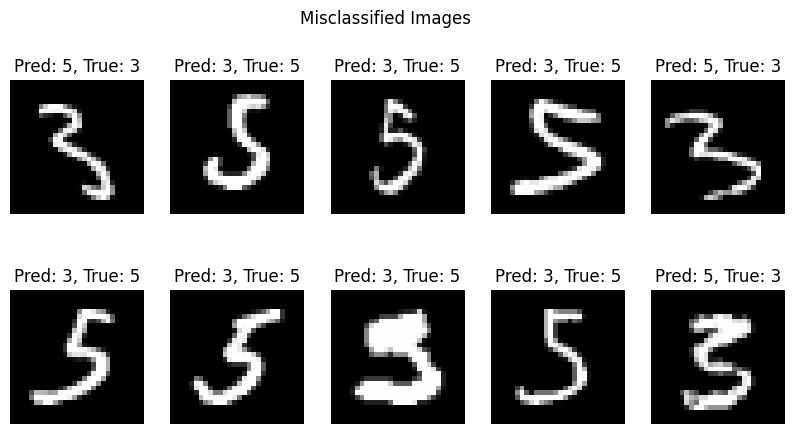

In [76]:
# Convert labels to 0/1
y_binary = np.where(y == 5, 1, 0)

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y_binary)
print(f"Final Accuracy: {final_accuracy * 100:.2f}%")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y_binary)[0]

if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {5 if y_pred[idx] == 1 else 3}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")